# Downloading the dataset

In [12]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

import os

We create a separate folder for our GeoPose3K dataset. This separates it from the synthetic data.

In [ ]:
os.makedirs(here() / "data/geopose3k", exist_ok=True)

GeoPose3K dataset has split the images into train, test and validation sets. This information is in the `geoPose3K_splits.zip` file.

In [ ]:
splits_zip = here() / "data/geoPose3K_splits.zip"
splits_url = "https://cphoto.fit.vutbr.cz/geoPose3K/data/geoPose3K_splits.zip"

In [11]:
import zipfile
import urllib.request

In [ ]:
if not os.path.exists(here() / "data/geopose3k/splits"):
    if not os.path.exists(splits_zip):
        print("Downloading train/test splits...")
        urllib.request.urlretrieve(splits_url, splits_zip)

    print("Extracting splits...")
    with zipfile.ZipFile(splits_zip, "r") as zip_ref:
        zip_ref.extractall(here() / "data/geopose3k/splits")

    os.remove(splits_zip)
    print("Splits extracted.")

In [ ]:
dataset_tar = here() / "data/geoPose3K_final_publish.tar.gz"
dataset_url = "http://merlin.fit.vutbr.cz/elevation/geoPose3K_final_publish.tar.gz"

In [14]:
import tarfile

In [ ]:
if not os.path.exists(here() / "data/geopose3k/final_publish"):
    if not os.path.exists(dataset_tar):
        print("Downloading full GeoPose3K dataset (This may take some time)...")
        urllib.request.urlretrieve(dataset_url, dataset_tar)

    print("Extracting dataset...")
    with tarfile.open(dataset_tar, "r:gz") as tar_ref:
        tar_ref.extractall(here() / "data/geopose3k")

    os.remove(dataset_tar)
    print("Dataset extracted.")

Extracting dataset...
Dataset extracted.


This is our complete GeoPose3K dataset:

In [13]:
base_dir = here() / "data/geopose3k/geoPose3K_final_publish"

<hr/>

# Understanding the dataset

Let's try to understand the structure of dataset.

In [ ]:
with open(here() / "data/geopose3k/geoPose3K_final_publish/README", "r") as f:
    print(f.read())

   _____            _____               ____  _  __
  / ____|          |  __ \             |___ \| |/ /
 | |  __  ___  ___ | |__) |__  ___  ___  __) | ' / 
 | | |_ |/ _ \/ _ \|  ___/ _ \/ __|/ _ \|__ <|  <  
 | |__| |  __/ (_) | |  | (_) \__ \  __/___) | . \ 
  \_____|\___|\___/|_|   \___/|___/\___|____/|_|\_\
                                                   
authors:        Jan Brejcha <brejchaja@gmail.com>
                Martin Čadík <cadik@fit.vut.cz, cadikm@centrum.cz>
affiliation:    Brno University of Technology, 
                Faculty of Information Technology
                                                   
GeoPose3K is a dataset of more than three thousand photos with precise 
annotations of camera position and orientation. Each photo is accompanied
with additional metadata rendered from a digital elevation model, specifically
depth, normals w.r.t. cardinal direction and camera, semantic labels obtained
from a GIS database (forest, glacier, bodies of water, etc.), and 

Let's see how the train/test/validation split information is given:

In [ ]:
train_file_path = None
for root, dirs, files in os.walk(here() / "data/geopose3k"):
    if "geoPose3K_final_train.txt" in files:
        train_file_path = os.path.join(root, "geoPose3K_final_train.txt")
        break

if train_file_path:
    print(f"Reading first 5 lines of '{train_file_path}':\n")
    with open(train_file_path, "r") as f:
        for _ in range(5):
            print(f.readline().strip())
else:
    print("geoPose3K_final_train.txt not found.")

Reading first 5 lines of 'data/geopose3k/geoPose3K_final_publish/geoPose3K_final_train.txt':

28488116812_f5a57ca0f6_k
28561570606
eth_ch1_1332166_01024
eth_ch1_2011-04-30_18:37:52_01024
eth_ch1_2011-04-30_18:40:20_01024


In [ ]:
sample_folder = os.path.join(base_dir, "28488116812_f5a57ca0f6_k")
mask_path = os.path.join(sample_folder, "pinhole/labels_crop.png")

if os.path.exists(mask_path):
    mask_arr = np.array(Image.open(mask_path))
    print(f"Unique pixel values in 'labels_crop.png': {np.unique(mask_arr)}")
else:
    print("Mask file not found at the expected path.")

Unique pixel values in 'labels_crop.png': [  0  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169
 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241
 242 243 244 245 246 247 248 249 250 251 252 253 254 255]


The values seem to be between 0 and 255.

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
sample = "eth_ch1_04032011388_01024"
sample_img_path = os.path.join(base_dir, sample, "photo.jpg")
sample_mask_path = os.path.join(base_dir, sample, "pinhole", "labels_crop.png")

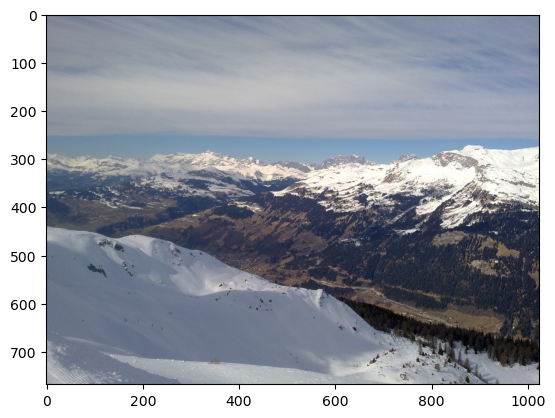

In [15]:
if os.path.exists(sample_img_path):
    plt.imshow(Image.open(sample_img_path))
    plt.show()

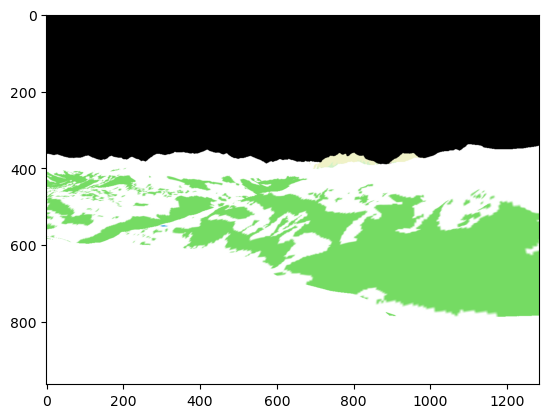

In [16]:
if os.path.exists(sample_mask_path):
    plt.imshow(Image.open(sample_mask_path), cmap='gray')
    plt.show()

The dataset neatly gives the skymasks we require.
`0 (black) = sky`